In [19]:
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
df = pd.read_csv("estat_earn_mw_cur.tsv",sep="\t")

In [20]:
country_names = {
    "AL": "Albania", "AT": "Austria", "AU": "Australia", "BA": "Bosnia and Herzegovina",
    "BE": "Belgium", "BG": "Bulgaria", "BY": "Belarus", "CH": "Switzerland",
    "CY": "Cyprus", "CZ": "Czechia", "DE": "Germany", "DK": "Denmark",
    "EA20": "Euro area (20 countries)", "EE": "Estonia", "EL": "Greece",
    "ES": "Spain", "EU27_2020": "European Union (27 countries)",
    "FI": "Finland", "FR": "France", "GE": "Georgia", "HR": "Croatia",
    "HU": "Hungary", "IE": "Ireland", "IS": "Iceland", "IT": "Italy",
    "LT": "Lithuania", "LU": "Luxembourg", "LV": "Latvia", "MD": "Moldova",
    "ME": "Montenegro", "MK": "North Macedonia", "MT": "Malta", "NL": "Netherlands",
    "NO": "Norway", "PL": "Poland", "PT": "Portugal", "RO": "Romania",
    "RS": "Serbia", "RU": "Russia", "SE": "Sweden", "SI": "Slovenia",
    "SK": "Slovakia", "TR": "Turkey", "UA": "Ukraine", "UK": "United Kingdom",
    "US": "United States", "XK": "Kosovo", "AM": "Armenia", "AZ": "Azerbaijan"
}

BG_COLOR        = "#0D1117"
CARD_COLOR      = "#161B22"
GRID_COLOR      = "#21262D"
BORDER_COLOR    = "#30363D"

TEXT_COLOR       = "#E6EDF3"
TEXT_SECONDARY   = "#8B949E"
AXIS_LABEL_COLOR = "#C9D1D9"
TICK_COLOR       = "#8B949E"
TITLE_COLOR      = "#FFFFFF"
SUBTITLE_COLOR   = "#8B949E"
ANNOTATION_COLOR = "#58A6FF"

BAR_COLORS = ["#6C8EBF", "#67A9A6", "#7FB069", "#A3B565", "#C9B458",
              "#D9A05B", "#D98C5F", "#C97B84", "#A87CA0", "#8479B0"]

POSITIVE_COLOR  = "#3FB950"
NEGATIVE_COLOR  = "#F85149"
HIGHLIGHT_COLOR = "#58A6FF"
MUTED_COLOR     = "#30363D"

In [21]:
column = df[r"freq,currency,geo\TIME_PERIOD"].str.split(",",expand=True)
df=df.drop(columns=r"freq,currency,geo\TIME_PERIOD")
df.insert(0,"geo",column[2].map(country_names))
df.insert(1,"currency",column[1])

In [22]:
df = df.melt(id_vars=["geo","currency"],var_name="period",value_name="amount")
df = df[df["currency"]=="EUR"]
df["period"] = df["period"].str.strip()
df["amount"] = df["amount"].astype(str).replace(":",None,regex=True)
df["amount"] = pd.to_numeric(df["amount"])
df=df.dropna(subset="amount")
df=df.drop(columns="currency")
df=df.reset_index(drop=True)
df

,geo,period,amount
0,Belgium,1999-S1,1074.0
1,Bulgaria,1999-S1,31.0
2,Czechia,1999-S1,92.0
3,Estonia,1999-S1,80.0
4,Greece,1999-S1,505.0
...,...,...,...
1526,Slovenia,2026-S1,1278.0
1527,Slovakia,2026-S1,915.0
1528,Turkey,2026-S1,654.0
1529,Ukraine,2026-S1,173.0


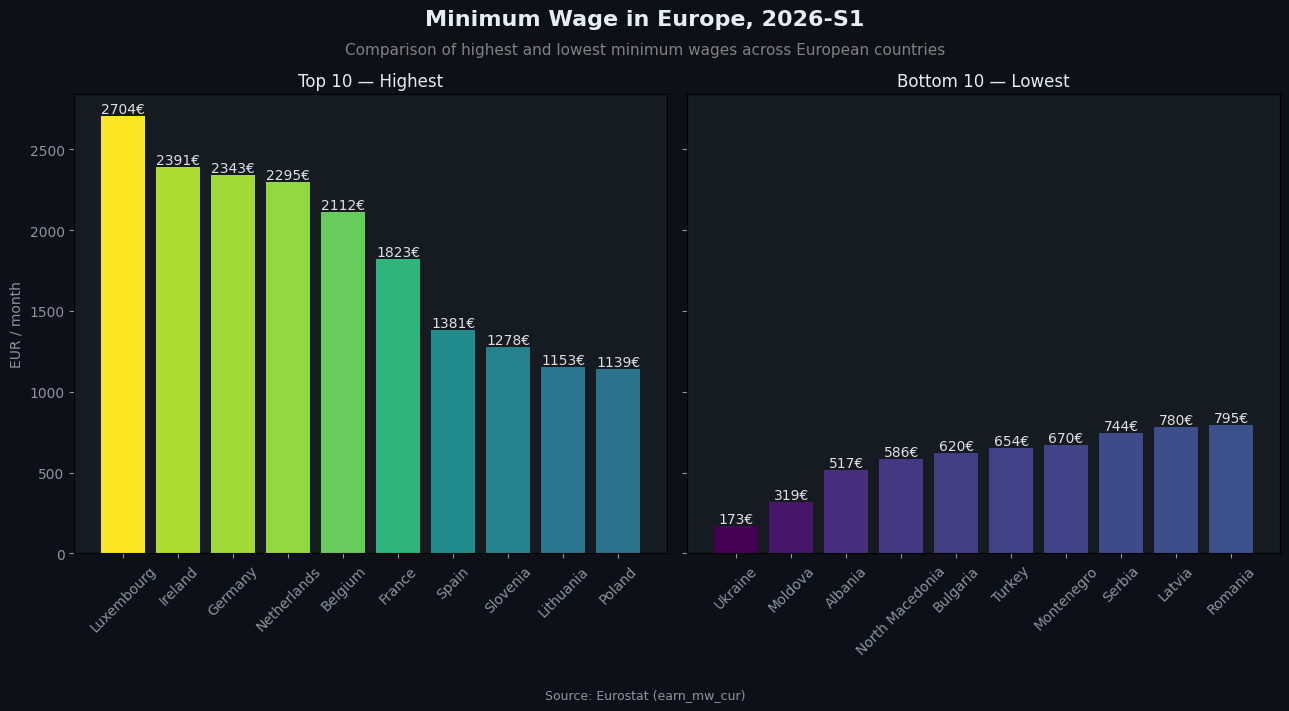

In [23]:
df_2026 = df[df["period"]=="2026-S1"]
df_2026_top10=df_2026.sort_values(by="amount",ascending=False).head(10)
df_ax1_x = df_2026_top10["geo"]
df_ax1_y = df_2026_top10["amount"]

df_2026_bottom10=df_2026.sort_values(by="amount").head(10)
df_ax2_x = df_2026_bottom10["geo"]
df_ax2_y = df_2026_bottom10["amount"]

df_all=df_2026["amount"]

norm = mpl.colors.Normalize(vmin=df_all.min(), vmax=df_all.max())
cmap = mpl.colormaps["viridis"]
colors_ax1 = [cmap(norm(v)) for v in df_ax1_y]
colors_ax2 = [cmap(norm(v)) for v in df_ax2_y]

fig,(ax1,ax2) = plt.subplots(1,2, sharey=True,figsize=(13,6.5),facecolor=BG_COLOR)
bars1=ax1.bar(df_ax1_x,df_ax1_y,color = colors_ax1)
ax1.set_facecolor(CARD_COLOR)
ax1.tick_params(axis="x",colors=TICK_COLOR,rotation=45)
ax1.tick_params(axis="y",colors=TICK_COLOR)
ax1.bar_label(bars1,labels=[f"{int(x)}€" for x in df_ax1_y],color="#E0E0E0")
ax1.set_title("Top 10 — Highest",color=TEXT_COLOR)

bars2=ax2.bar(df_ax2_x,df_ax2_y,color = colors_ax2)
ax2.set_facecolor(CARD_COLOR)
ax2.tick_params(axis="x",colors=TICK_COLOR,rotation=45)
ax2.tick_params(axis="y",colors=TICK_COLOR)
ax2.bar_label(bars2,labels=[f"{int(x)}€" for x in df_ax2_y],color="#E0E0E0")
ax2.set_title("Bottom 10 — Lowest",color=TEXT_COLOR)

fig.text(0.5, -0.04,
         "Source: Eurostat (earn_mw_cur)",
         ha="center", color=TICK_COLOR, fontsize=9)

fig.suptitle("Minimum Wage in Europe, 2026-S1",
             color=TEXT_COLOR, fontsize=16, fontweight="bold", y=1.02)
ax1.set_ylabel("EUR / month",color=TICK_COLOR,fontsize=10)
plt.tight_layout()
plt.figtext(0.5, 0.95, 
    'Comparison of highest and lowest minimum wages across European countries', 
    ha='center', fontsize=11, color='gray')
plt.show()

## Minimum Wage in Europe: Top 10 vs Bottom 10 (2026-S1)

Comparison of the highest- and lowest-paying countries by statutory minimum wage across Europe, using the latest Eurostat data (`earn_mw_cur`, period 2026-S1).

Bar color encodes the wage level on a **shared scale** across both charts, so the same color always means the same amount — this makes the gap between the two groups immediately visible.

**Key findings:**

- **Luxembourg leads** at €2,704/month — the highest minimum wage in Europe.
- **Ukraine sits at the bottom** with €173/month — roughly **15.6× lower** than Luxembourg.
- The entire Bottom 10 group stays in the cool (dark) color range: even Romania (€795), the highest among them, falls near the bottom of the Europe-wide scale.
- A clear **East-West divide**: Western and Northern economies dominate the top, while South-Eastern Europe and non-EU countries cluster at the bottom.

In [24]:
def get_growth(x):
    x = x[x["period"].astype(str).str.endswith("S1")]
    x = x.sort_values(by="period")
    first_amount = x["amount"].iloc[0]
    last_amount = x["amount"].iloc[-1]
    first_year = int(x["period"].iloc[0][:4])
    last_year = int(x["period"].iloc[-1][:4])
    years = last_year - first_year
    cagr = ((last_amount / first_amount) ** (1 / years) - 1) * 100
    return round(cagr, 1)
    

last_table = df.sort_values(by="period").groupby("geo").tail(1).reset_index(drop=True)
growth_table = df.groupby("geo").apply(get_growth).reset_index()
growth_table.columns = ["geo","growth"]
growth_table=growth_table.sort_values(by="growth")

amount_and_growth_table = pd.merge(last_table,growth_table,on="geo",how="inner")
amount_and_growth_table=amount_and_growth_table.drop(columns="period")
amount_and_growth_table.sort_values(by="growth",ascending=False)

,geo,amount,growth
1,Moldova,319.0,21.5
8,Romania,795.0,13.3
9,Serbia,744.0,12.2
25,Bulgaria,620.0,11.7
28,Ukraine,173.0,10.2
11,Slovakia,915.0,10.0
29,Lithuania,1153.0,9.8
27,Albania,517.0,9.7
21,Estonia,886.0,9.3
12,Latvia,780.0,9.1


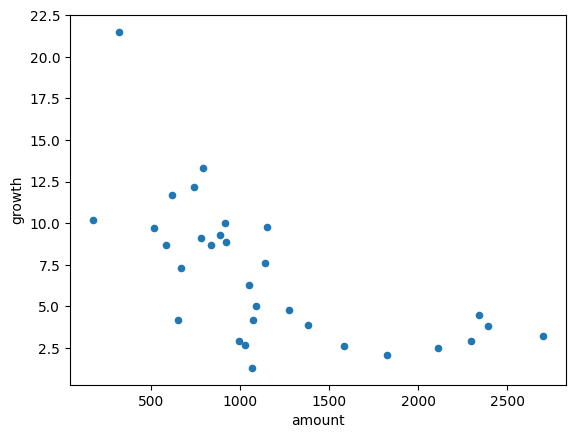

In [25]:
ax = amount_and_growth_table.plot.scatter(x="amount",y="growth")

## Growth vs. Current Wage Level

This chart plots CAGR (average annual growth) against each country's current minimum wage. There's a clear pattern: **the higher the current wage, the slower it grows in percentage terms.**

- Countries like **Luxembourg** or **Ireland**, where wages are already high, show growth around **2–5% per year**.
- Countries like **Moldova** or **Serbia**, with wages several times lower, are growing at **15–20%+**.

This doesn't mean poorer countries are catching up at some remarkable pace. It's mostly arithmetic: when the starting wage is small, even a modest increase in euros translates into a large percentage. The same euro increase for Luxembourg would barely register as a percentage, simply because the base is already large.

**In short:** this chart reinforces what the earlier table already showed — the high growth rates in lower-income countries are mostly a function of their low starting point, not unusually fast economic development.

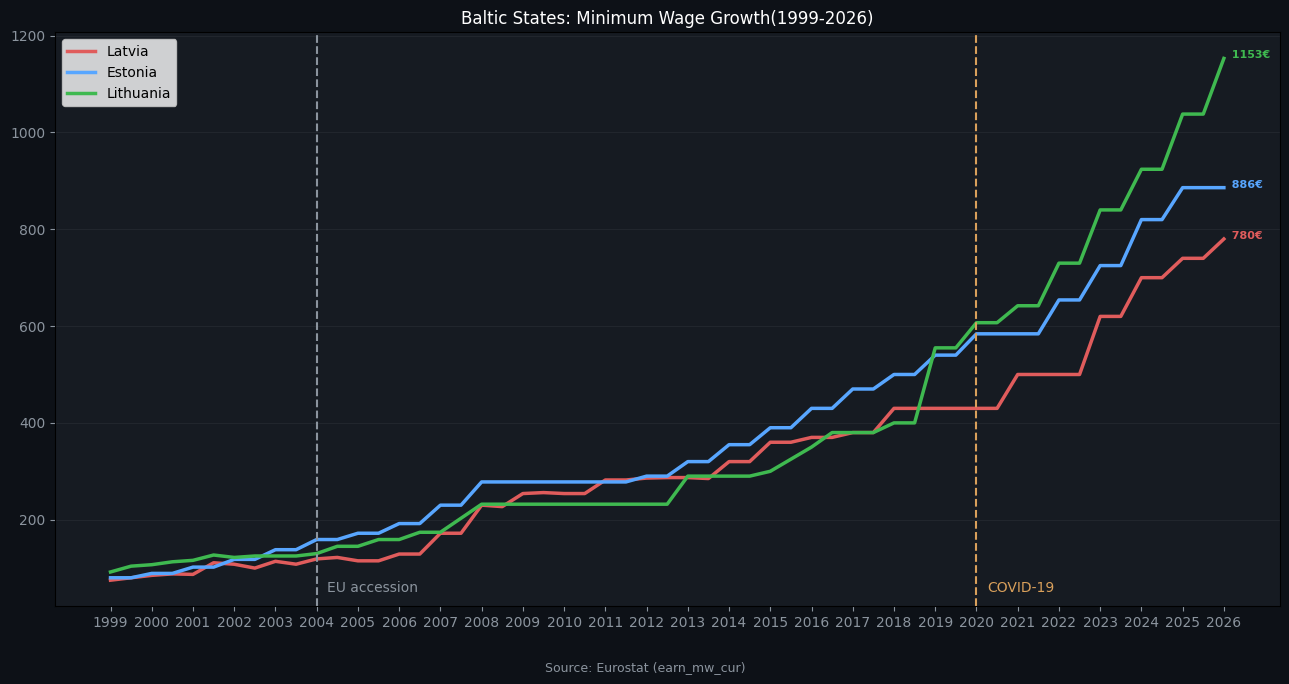

In [26]:
df_Latvia = df[df["geo"]=="Latvia"]
df_Estonia = df[df["geo"]=="Estonia"]
df_Lithuania = df[df["geo"]=="Lithuania"]

x = df_Latvia["period"]

fig,ax = plt.subplots(figsize=(13,6.5),facecolor=BG_COLOR)
ax.set_facecolor(CARD_COLOR)
ax.plot(x,df_Latvia["amount"],label="Latvia",color="#E05C5C",linewidth=2.5)
ax.plot(x,df_Estonia["amount"],label="Estonia",color="#58A6FF",linewidth=2.5)
ax.plot(x,df_Lithuania["amount"],label="Lithuania",color="#3FB950",linewidth=2.5)
ax.axvline(x=10,color=TEXT_SECONDARY,linestyle="--")
ax.axvline(x=42,color="#D9A05B",linestyle="--")
ax.xaxis.set_ticks(ticks=[i for i in x[::-2]],labels=[j[:4] for j in x[::-2]])
ax.tick_params(axis="x",colors=TICK_COLOR)
ax.tick_params(axis="y",colors=TICK_COLOR)
ax.text(x=10.5,y=50,s="EU accession",color=TEXT_SECONDARY)
ax.text(x=42.5,y=50,s="COVID-19",color="#D9A05B")
for df1, color in(df_Latvia,"#E05C5C"), (df_Estonia,"#58A6FF"),(df_Lithuania,"#3FB950"):
    last = df1.iloc[-1]
    ax.text(last["period"],last["amount"],f"  {int(last["amount"])}€",color=color,fontsize=8,fontweight="bold")

plt.title("Baltic States: Minimum Wage Growth(1999-2026)",color=TITLE_COLOR)
plt.legend()
plt.tight_layout()
ax.yaxis.grid(True,color=GRID_COLOR)
fig.text(0.5, -0.04,
         "Source: Eurostat (earn_mw_cur)",
         ha="center", color=TICK_COLOR, fontsize=9)
plt.show()

## Baltic States: Minimum Wage Growth (1999–2026)

All three started around **€80–100/month**, moving roughly together through the **2004 EU accession**. **Estonia** was the first to pull ahead, opening a visible lead by around 2008–2009 and holding it for the next decade.

By 2018–2019 the three were already clearly apart, well before COVID: **Latvia** had entered a flat stretch around **€430**, while Estonia and Lithuania kept climbing. The gap widened further after COVID, when **Lithuania's** growth accelerated sharply, overtaking Estonia around 2022–2023 and finishing well in front:

- **Lithuania:** €1,153
- **Estonia:** €886
- **Latvia:** €780

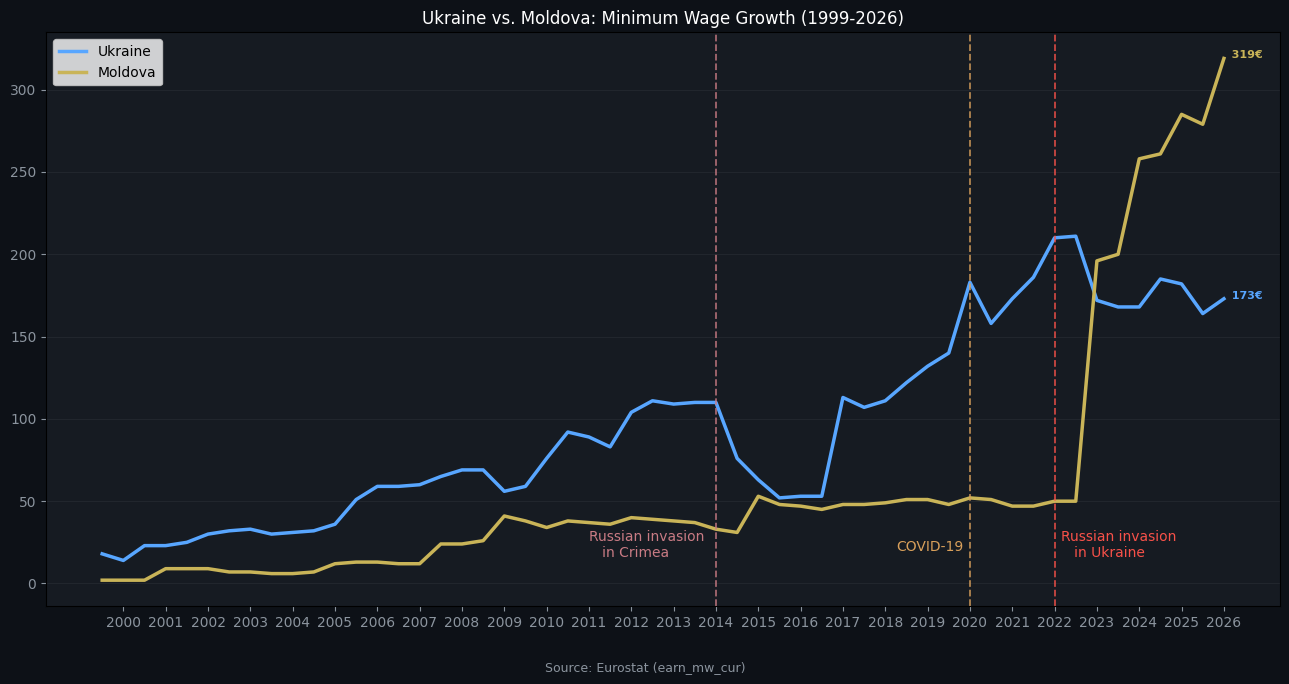

In [27]:
df_Ukraine = df[df["geo"]=="Ukraine"]
df_Moldova = df[df["geo"]=="Moldova"]

x = df_Moldova["period"]

UKRAINE_COLOR = "#58A6FF"
MOLDOVA_COLOR = "#C9B458"

CRIMEA_COLOR = "#C97B84"
INVASION_COLOR = "#F85149"
COVID_COLOR = "#D9A05B"

fig,ax = plt.subplots(figsize=(13,6.5),facecolor=BG_COLOR)
ax.set_facecolor(CARD_COLOR)
ax.plot(x,df_Ukraine["amount"],label="Ukraine",color=UKRAINE_COLOR,linewidth=2.5)
ax.plot(x,df_Moldova["amount"],label="Moldova",color=MOLDOVA_COLOR,linewidth=2.5)

ax.axvline(x=41,color=COVID_COLOR,linestyle="--",linewidth=1.3,alpha=0.8)
ax.axvline(x=29,color=CRIMEA_COLOR,linestyle="--",linewidth=1.3,alpha=0.8)
ax.axvline(x=45,color=INVASION_COLOR,linestyle="--",linewidth=1.3,alpha=0.8)
ax.xaxis.set_ticks(ticks=[i for i in x[::-2]],labels=[j[:4] for j in x[::-2]])
ax.tick_params(axis="x",colors=TICK_COLOR)
ax.tick_params(axis="y",colors=TICK_COLOR)
ax.text(x=37.5,y=20,s="COVID-19",color=COVID_COLOR)
ax.text(x=23,y=16,s=f"Russian invasion \n   in Crimea",color=CRIMEA_COLOR)
ax.text(x=45.3,y=16,s=f"Russian invasion \n   in Ukraine",color=INVASION_COLOR)
for df2, color in(df_Ukraine,UKRAINE_COLOR), (df_Moldova,MOLDOVA_COLOR):
    last = df2.iloc[-1]
    ax.text(last["period"],last["amount"],f"  {int(last["amount"])}€",color=color,fontsize=8,fontweight="bold")

plt.title("Ukraine vs. Moldova: Minimum Wage Growth (1999-2026)",color=TITLE_COLOR)
plt.legend()
ax.yaxis.grid(True,color=GRID_COLOR)
fig.text(0.5, -0.04,
         "Source: Eurostat (earn_mw_cur)",
         ha="center", color=TICK_COLOR, fontsize=9)
plt.tight_layout()
plt.show()

## Why the Euro-Denominated Wage Plateaued

The flat line after 2022 likely isn't just a currency quirk sitting on top of strong wage growth. Two opposing forces are probably at play:

- The **hryvnia value** of the minimum wage did rise during the war years, which would normally push the euro figure up.
- The **currency also lost value** against the euro over the same period, pulling the euro figure back down.

The depreciation appears to have outpaced the wage increases, which is why the euro-denominated line ends up flat instead of rising.